This program creates a model that can predicts the cost of healthcare services using a linear regression model. Initial code from FreeCodeCamp.

In [ ]:
# Import libraries. You may or may not use all of these.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
  # %tensorflow_version only exists in Colab.
  %tensorflow_version 2.x
except Exception:
  pass
import tensorflow as tf


Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [ ]:
!wget "https://cdn.freecodecamp.org/project-data/health-costs/insurance.csv"
df = pd.read_csv("insurance.csv")
df.tail()

--2025-09-08 21:21:35--  https://cdn.freecodecamp.org/project-data/health-costs/insurance.csv
Resolving cdn.freecodecamp.org (cdn.freecodecamp.org)... 104.26.3.33, 172.67.70.149, 104.26.2.33, ...
Connecting to cdn.freecodecamp.org (cdn.freecodecamp.org)|104.26.3.33|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50264 (49K) [text/csv]
Saving to: ‘insurance.csv’

insurance.csv       100%[===================>]  49.09K  --.-KB/s    in 0.004s  

2025-09-08 21:21:36 (11.5 MB/s) - ‘insurance.csv’ saved [50264/50264]



,age,sex,bmi,children,smoker,region,expenses
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95
1337,61,female,29.1,0,yes,northwest,29141.36


In [ ]:
df = df.join(pd.get_dummies(df.region, prefix='region')).drop('region', axis=1)
df.head()

labels = {}

values        = df.sex.astype('category')
labels['sex'] = values.cat.categories
df['sex']     = values.cat.codes

df.head()

,age,sex,bmi,children,smoker,expenses,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.9,0,yes,16884.92,False,False,False,True
1,18,1,33.8,1,no,1725.55,False,False,True,False
2,28,1,33.0,3,no,4449.46,False,False,True,False
3,33,1,22.7,0,no,21984.47,False,True,False,False
4,32,1,28.9,0,no,3866.86,False,True,False,False


In [ ]:
values           = df.smoker.astype('category')
labels['smoker'] = values.cat.categories
df['smoker']     = values.cat.codes

df.head()

,age,sex,bmi,children,smoker,expenses,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.9,0,1,16884.92,False,False,False,True
1,18,1,33.8,1,0,1725.55,False,False,True,False
2,28,1,33.0,3,0,4449.46,False,False,True,False
3,33,1,22.7,0,0,21984.47,False,True,False,False
4,32,1,28.9,0,0,3866.86,False,True,False,False


<Axes: >

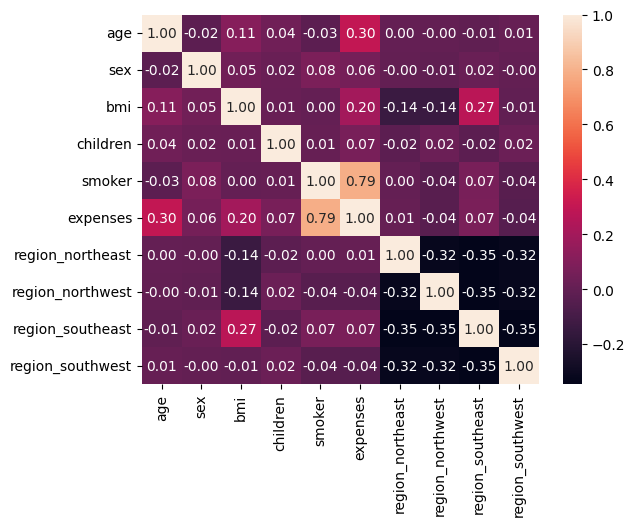

In [ ]:
sns.heatmap(df.corr(), annot=True, fmt='.2f')

In [ ]:
df.drop(['region_northeast', 'region_northwest', 'region_southeast', 'region_southwest'], axis=1, inplace=True)


In [ ]:
df.drop(['sex', 'children'], axis=1, inplace=True)


In [ ]:
df = df.sample(frac=1)
size          = int(len(df) * .2)
train_dataset = df[:-size]
test_dataset  = df[-size:]
train_labels  = train_dataset['expenses']
train_dataset = train_dataset.drop('expenses', axis=1)
test_labels   = test_dataset['expenses']
test_dataset  = test_dataset.drop('expenses', axis=1)

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(len(train_dataset.keys()),)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])
model.compile(
    optimizer= tf.keras.optimizers.RMSprop(0.05),
    loss='mse',
    metrics=['mae', 'mse']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 3)              │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,493 (17.55 KB)

 Trainable params: 4,487 (17.53 KB)

 Non-trainable params: 6 (24.00 B)

In [ ]:
# from tfdocs.modeling.EpochDots
class EpochDots(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs):
    if epoch % 100 == 0:
      print()
      print('Epoch: {:d}, '.format(epoch), end='')
      for name, value in sorted(logs.items()):
        print('{}:{:0.4f}'.format(name, value), end=', ')
      print()

    print('.', end='')

r = model.fit(train_dataset, train_labels, epochs=500,
              verbose=0, callbacks=[EpochDots()])


Epoch: 0, loss:106783256.0000, mae:6566.7588, mse:106783256.0000, 
....................................................................................................
Epoch: 100, loss:26127490.0000, mae:3150.8152, mse:26127490.0000, 
....................................................................................................
Epoch: 200, loss:24220774.0000, mae:2908.3401, mse:24220774.0000, 
....................................................................................................
Epoch: 300, loss:23295988.0000, mae:2867.1294, mse:23295988.0000, 
....................................................................................................
Epoch: 400, loss:23522594.0000, mae:2880.9988, mse:23522594.0000, 
....................................................................................................

In [ ]:
res = model.evaluate(test_dataset, test_labels, verbose=2)
print(res)

9/9 - 0s - 33ms/step - loss: 19393752.0000 - mae: 2893.4695 - mse: 19393752.0000
[19393752.0, 2893.469482421875, 19393752.0]


9/9 - 0s - 8ms/step - loss: 19393752.0000 - mae: 2893.4695 - mse: 19393752.0000
Testing set Mean Abs Error: 2893.47 expenses
You passed the challenge. Great job!
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


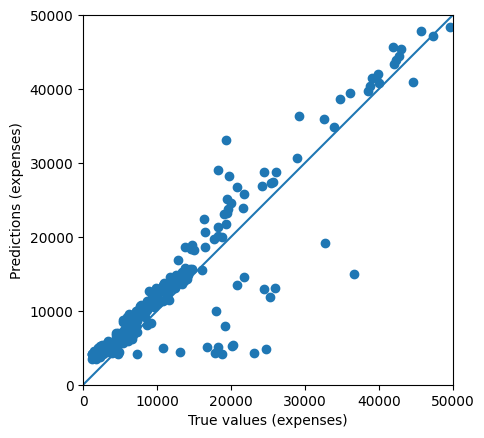

In [ ]:
# RUN THIS CELL TO TEST YOUR MODEL. DO NOT MODIFY CONTENTS.
# Test model by checking how well the model generalizes using the test set.
loss, mae, mse = model.evaluate(test_dataset, test_labels, verbose=2)

print("Testing set Mean Abs Error: {:5.2f} expenses".format(mae))

if mae < 3500:
  print("You passed the challenge. Great job!")
else:
  print("The Mean Abs Error must be less than 3500. Keep trying.")

# Plot predictions.
test_predictions = model.predict(test_dataset).flatten()

a = plt.axes(aspect='equal')
plt.scatter(test_labels, test_predictions)
plt.xlabel('True values (expenses)')
plt.ylabel('Predictions (expenses)')
lims = [0, 50000]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims,lims)
